### Happy Customers
We are one of the fastest growing startups in the logistics and delivery domain. We work with several partners and make on-demand delivery to our customers. From operational standpoint we have been facing several different challenges and everyday we are trying to address these challenges.

We thrive on making our customers happy. As a growing startup, with a global expansion strategy we know that we need to make our customers happy and the only way to do that is to measure how happy each customer is. If we can predict what makes our customers happy or unhappy, we can then take necessary actions.

Getting feedback from customers is not easy either, but we do our best to get constant feedback from our customers. This is a crucial function to improve our operations across all levels.

We recently did a survey to a select customer cohort. You are presented with a subset of this data. We will be using the remaining data as a private test set.

**Data Description:**

Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers</br>
X1 = my order was delivered on time</br>
X2 = contents of my order was as I expected</br>
X3 = I ordered everything I wanted to order</br>
X4 = I paid a good price for my order</br>
X5 = I am satisfied with my courier</br>
X6 = the app makes ordering easy for me</br>

Attributes X1 to X6 indicate the responses for each question and have values from 1 to 5 where the smaller number indicates less and the higher number indicates more towards the answer.

**Goal(s):**

Predict if a customer is happy or not based on the answers they give to questions asked.

**Success Metrics:**

Reach 73% accuracy score or above, or convince us why your solution is superior. We are definitely interested in every solution and insight you can provide us.

Try to submit your working solution as soon as possible. The sooner the better.

**Bonus(es):**

We are very interested in finding which questions/features are more important when predicting a customer’s happiness. Using a feature selection approach show us understand what is the minimal set of attributes/features that would preserve the most information about the problem while increasing predictability of the data we have. Is there any question that we can remove in our next survey?

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To get diferent metric scores
from sklearn.metrics import (
     f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)


# To supress warnings
import warnings

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
Review= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ACME-HappinessSurvey2020.csv')

In [ ]:
df=Review.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [ ]:
df.tail()

,Y,X1,X2,X3,X4,X5,X6
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5
125,0,5,3,2,5,5,5


In [ ]:
df.shape


(126, 7)

* 126 rows and 7 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


* All column data type is integer and there are no null values.

In [ ]:
df.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000,126.000,126.000,126.000,126.000,126.000,126.000
mean,0.548,4.333,2.532,3.310,3.746,3.651,4.254
std,0.500,0.800,1.115,1.023,0.876,1.148,0.809
min,0.000,1.000,1.000,1.000,1.000,1.000,1.000
25%,0.000,4.000,2.000,3.000,3.000,3.000,4.000
50%,1.000,5.000,3.000,3.000,4.000,4.000,4.000
75%,1.000,5.000,3.000,4.000,4.000,4.000,5.000
max,1.000,5.000,5.000,5.000,5.000,5.000,5.000


•	On time order delivery means rating is 4.33 and apps make ordering easy mean rating is 4.25
•	Expectation of content means rating is lowest among all rating which is 2.5.
•	All ratings are between 1 and 5.


In [ ]:
df.isnull().sum()

,0
Y,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0


* There is no null value in the data.

In [ ]:
df['Y'].value_counts(normalize=True)

,proportion
Y,
1,0.548
0,0.452


* About 55% of the customers are happy and 45% are unhappy.

In [ ]:
# Show unique values for X1–X5
for col in ['X1', 'X2', 'X3', 'X4', 'X5']:
    print(f'Unique values for {col}: {df[col].unique()}')

Unique values for X1: [3 5 4 1]
Unique values for X2: [3 2 4 5 1]
Unique values for X3: [3 2 4 5 1]
Unique values for X4: [4 5 3 2 1]
Unique values for X5: [2 4 3 5 1]


* All review column rated between 1 to 5 which is discrete value, Column X1 didn't receive rating 2.

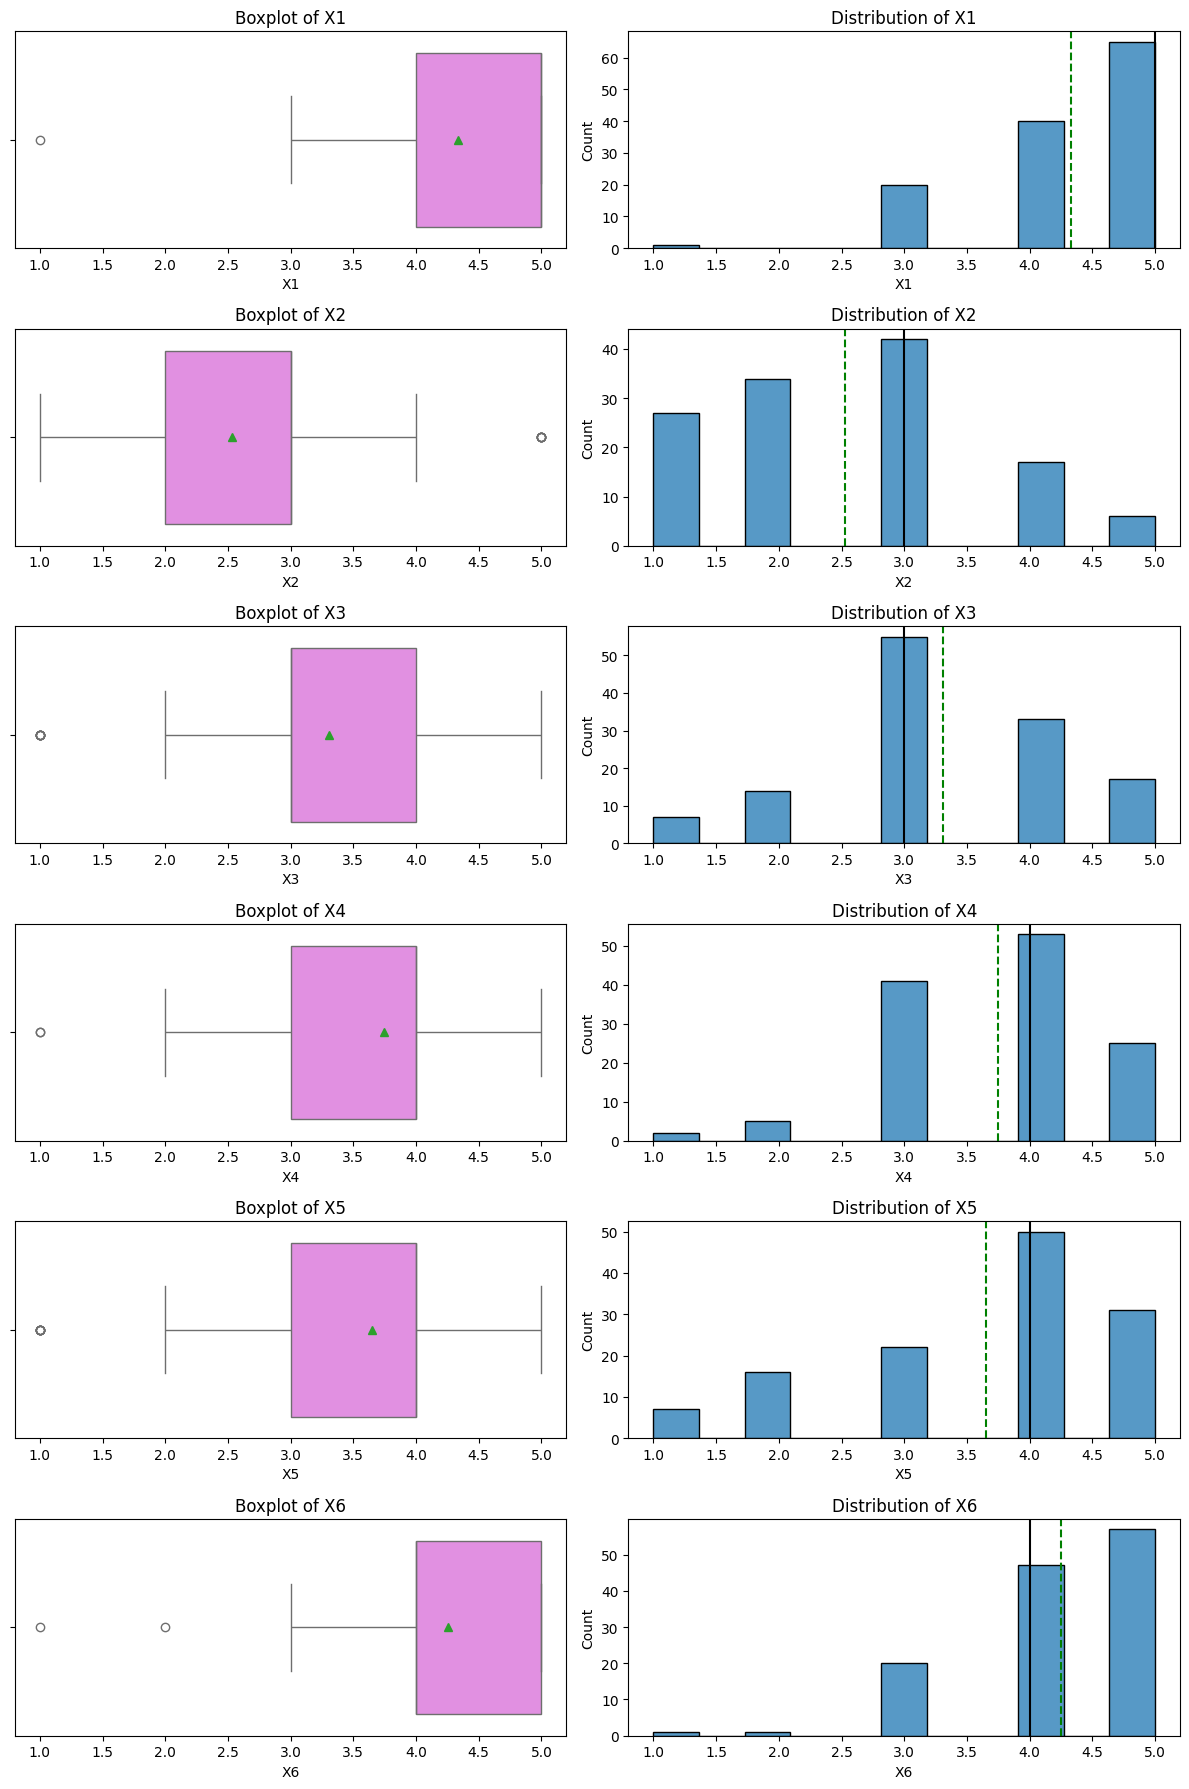

In [ ]:
features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(12, 18))
for i, feat in enumerate(features):
    sns.boxplot(data=df, x=feat, ax=axes[i, 0], showmeans=True, color="violet")
    axes[i, 0].set_title(f'Boxplot of {feat}')
    sns.histplot(data=df, x=feat, ax=axes[i, 1], kde=False)
    axes[i, 1].axvline(df[feat].mean(), color="green", linestyle="--")
    axes[i, 1].axvline(df[feat].median(), color="black", linestyle="-")
    axes[i, 1].set_title(f'Distribution of {feat}')

plt.tight_layout()
plt.show()


In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=60, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

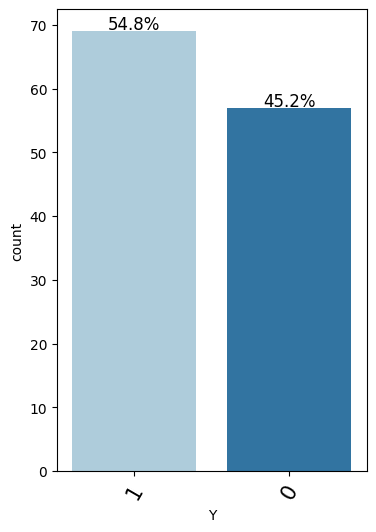

In [ ]:
labeled_barplot(df,"Y", perc=True)


•	Distribution of Dependent variable is unbalanced which means data is biased.


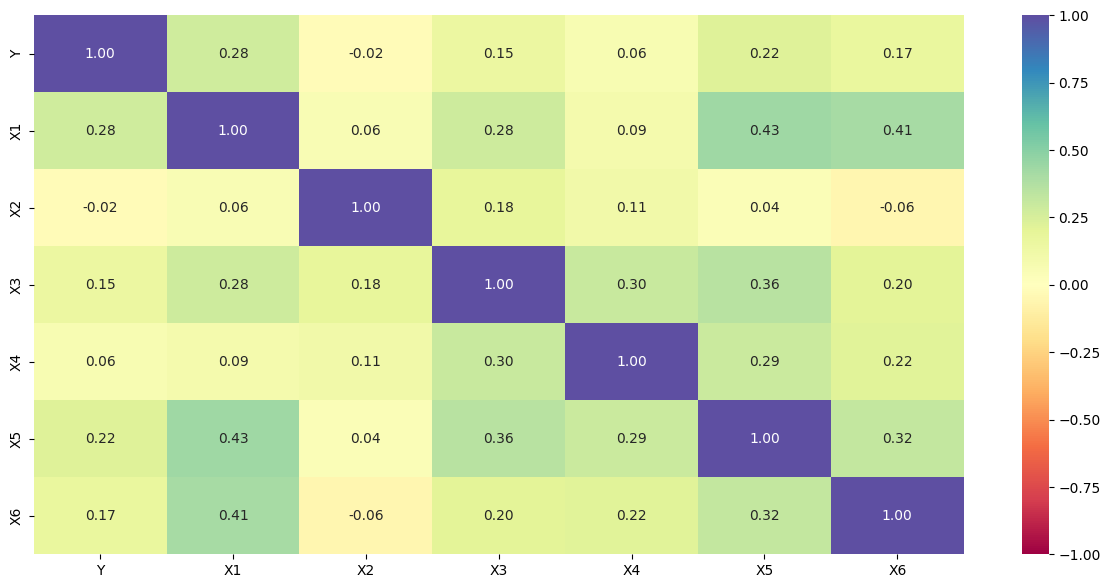

In [ ]:
plt.figure(figsize=(15, 7))
# Selecting only numerical features for correlation analysis
numerical_data = data.select_dtypes(include=np.number)
sns.heatmap(numerical_data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* There is no strong correlation between independent variables and dependent variable "y".
* There is correlation positive correlation between X1 and X5, and X1 and X6 which means order delivery on time makes customer satisfied with the courier service.


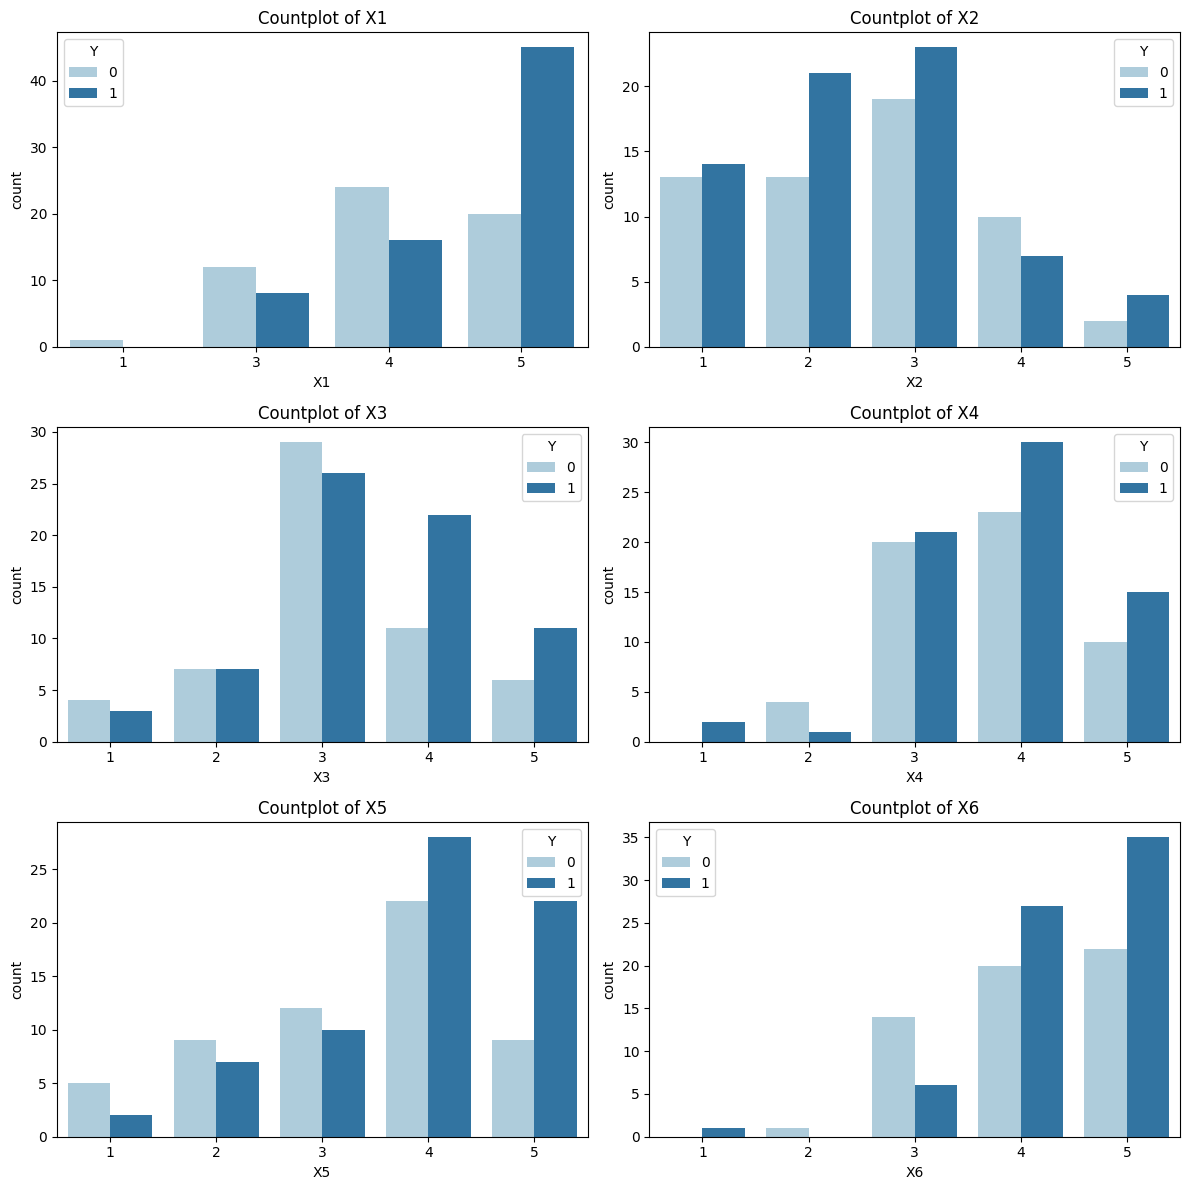

In [ ]:
features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.ravel()

for ax, feat in zip(axes, features):
    sns.countplot(data=df, x=feat, hue='Y', ax=ax, palette='Paired', order=sorted(df[feat].unique()))
    ax.set_title(f'Countplot of {feat}')
    ax.legend(title='Y')

plt.tight_layout()
plt.show()


•	 X1, X4, X5 and X6 features received more positive ratings than other columns

### **Approach 1**
* We will first build logistic regression model which called baseline model to see how our data reacts to this model. It will help us establish a minimum performance threshold, allowing to justify or decide against, using advanced models.

In [ ]:
# specifying the independent  and dependent variables
X = df.drop(["Y"], axis=1)
Y = df["Y"]
# adding a constant to the independent variables
X = sm.add_constant(X)
# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (88, 7)
Shape of test set :  (38, 7)
Percentage of classes in training set:
Y
1   0.523
0   0.477
Name: proportion, dtype: float64
Percentage of classes in test set:
Y
1   0.605
0   0.395
Name: proportion, dtype: float64


* Dependent variable y is unbalanced; we will use stratify to split train test set to balance it.

In [ ]:
# specifying the independent  and dependent variables
X = df.drop(["Y"], axis=1)
Y = df["Y"]
# adding a constant to the independent variables
X = sm.add_constant(X)
# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (88, 7)
Shape of test set :  (38, 7)
Percentage of classes in training set:
Y
1   0.545
0   0.455
Name: proportion, dtype: float64
Percentage of classes in test set:
Y
1   0.553
0   0.447
Name: proportion, dtype: float64


* Using a Stratify parameter during train test split helped us to ensure training and testing sets have the same proportion of classes

In [ ]:
df.shape

(126, 7)

In [ ]:
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


> **Checking Multicollinearity**
In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [ ]:
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)
print("VIF values: \n\n{}\n".format(vif_series))

VIF values: 

const   57.187
X1       1.587
X2       1.100
X3       1.386
X4       1.201
X5       1.552
X6       1.341
dtype: float64



* There is no multi collinearity present in the data.

**Building a Logistic Regression model**

In [ ]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit(disp=False)
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       81
Method:                           MLE   Df Model:                            6
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                 0.08039
Time:                        16:52:41   Log-Likelihood:                -55.759
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.1357
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6713      1.849     -1.986      0.047      -7.295      -0.047
X1             0.2692      0.350      0.768      0.442      -0.418       0.956
X2            -0.0921      0.225     -0.410      0.6

* Negative values of the coefficient show that the probability of booking cancellation decreases with the increase of the corresponding attribute value.

* Positive values of the coefficient show that the probability of booking cacellation increases with the increase of the corresponding attribute value.

* p-value of a variable indicates if the variable is significant or not. If we consider the significance level to be 0.05 (5%), then any variable with a p-value less than 0.05 would be considered significant.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

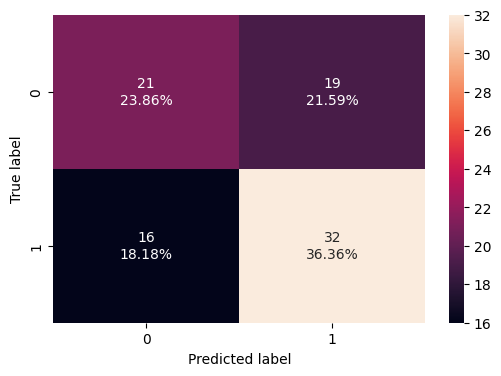

In [ ]:
confusion_matrix_statsmodels(lg, X_train, y_train)

Model evaluation criterion
Model can make wrong predictions such as:
•	Predicting that the customer is happy but in reality, the customer is not happy (FP)
•	Predicting the customer is not happy but in reality, the customer is happy (FN)
Which case is more important?
•	Company wants to predict happy customers so we will have to reduce FN which means we will maximize Recall.


In [ ]:
print("Training performance:")
model_performance_classification_statsmodels(lg, X_train, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.602,0.667,0.627,0.646


* The Recall of the model is ~0.67 and we will try to maximize it further
* We will have to remove high p-values

**Converting coefficients to odds to see which features are important**

* The coefficients ($\beta$s) of the logistic regression model are in terms of $log(odds)$ and to find the odds, we have to take the exponential of the coefficients
* Therefore, **$odds =  exp(\beta)$**
* The percentage change in odds is given as $(exp(\beta) - 1) * 100$

In [ ]:
# converting coefficients to odds
odds = np.exp(lg.params)

# finding the percentage change
perc_change_odds = (np.exp(lg.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train.columns).T

,const,X1,X2,X3,X4,X5,X6
Odds,0.025,1.309,0.912,1.282,1.213,1.330,1.081
Change_odd%,-97.456,30.896,-8.797,28.214,21.260,33.044,8.078


* Holding all other features constant a 1 unit change in X1 will increase the odds of gettiing happy customer by ~1.3 times or a ~31% increase in odds of booking getting canceled.
* Holding all other features constant a 1 unit change in X2 will decrease the odds of a booking getting canceled by ~0.91 times or a decrease of
~8.8% decrease in odds of booking getting canceled.
* Holding all other features constant a 1 unit change in X5 will increase the odds of gettiing happy customer by ~1.3 times or a ~33% increase in odds of booking getting canceled.

### Removing high p-value variables

In [ ]:
# initial list of columns
cols = X_train.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train[cols]

    # fitting the model
    model = sm.Logit(y_train, X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'X5']


* After dropping features one by one with higher P value, we have only one feature left X1.
* Our goal is inference (understanding relationships) so we will keep non-significant predictors.


In [ ]:
log_reg_model_train_perf = model_performance_classification_statsmodels(
    lg, X_train, y_train
)

print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.602,0.667,0.627,0.646


In [ ]:
log_reg_model_test_perf = model_performance_classification_statsmodels(
    lg, X_test, y_test
)

print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.579,0.714,0.600,0.652


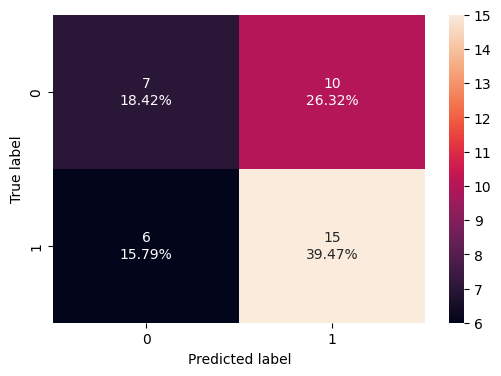

In [ ]:
confusion_matrix_statsmodels(lg, X_test, y_test)

•	Logistic Regression model gave recall that is little underfitting with 67% in training set and 71% in testing set which means model is very simple for the data but it generalized well. We can see if other models can maximize recall and accuracy.

•	According to Logistic Regression column X5 is very important feature followed by X1, X3, X4, X2 by looking at odds and change of odds in percentage. Column X6 is least likely to predict y variable according to this model.


### **Approach 2**
* We will try and see how other robust models work for our data

## Building a Decision Tree model

In [ ]:
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [ ]:
X = df.drop(["Y"], axis=1)
Y = df["Y"]

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (88, 6)
Shape of test set :  (38, 6)
Percentage of classes in training set:
Y
1   0.545
0   0.455
Name: proportion, dtype: float64
Percentage of classes in test set:
Y
1   0.553
0   0.447
Name: proportion, dtype: float64


In [ ]:
Dtree = DecisionTreeClassifier(random_state=1, class_weight="balanced")
Dtree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

In [ ]:
decision_tree_perf_train_without = model_performance_classification_statsmodels(
    Dtree, X_train, y_train
)
decision_tree_perf_train_without

,Accuracy,Recall,Precision,F1
0,0.932,0.875,1.000,0.933


* Decision tree tends to overfit so we will hyper tune it before giving it test data

* There is a huge disparity in performance of model on training set and test set, which suggests that the model is overfitting.
* We will do hyperparameter tuning to solve overfitting problem

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(Dtree.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

     Imp
X2 0.260
X3 0.219
X1 0.162
X6 0.133
X5 0.117
X4 0.109


* According to decision tree most important feature is X2 which is 26% important and least important feacher is X4 which is 11% important.

## Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "class_weight": [None, "balanced"],
    #"max_depth": np.arange(1, 7, 1), # op-out because we have 126 rows only.
    "max_leaf_nodes": [2, 5, 10, 20, 30],
    "min_samples_split": [10, 20, 30, 50, 70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_leaf_nodes=5,
                       min_samples_split=30, random_state=1)

* By using Grid search with cross validation, we found that class weight should be balanced, maximum depth should be 2, maximum leaf node should have 5 samples and minimum samples to do split is 30. Thay are the best parameters to get the best Recall.

In [ ]:
decision_tree_tune_perf_train = model_performance_classification_statsmodels(
    estimator, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.693,0.542,0.839,0.658


In [ ]:
decision_tree_tune_perf_test = model_performance_classification_statsmodels(
    estimator, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.605,0.381,0.800,0.516


* Hyperparameter tuned decision tree didn’t able to give best performance on recall but model’s precision score generalized well.


In [ ]:
feature_names = list(X_train.columns)
importances = estimator.feature_importances_
indices = np.argsort(importances)

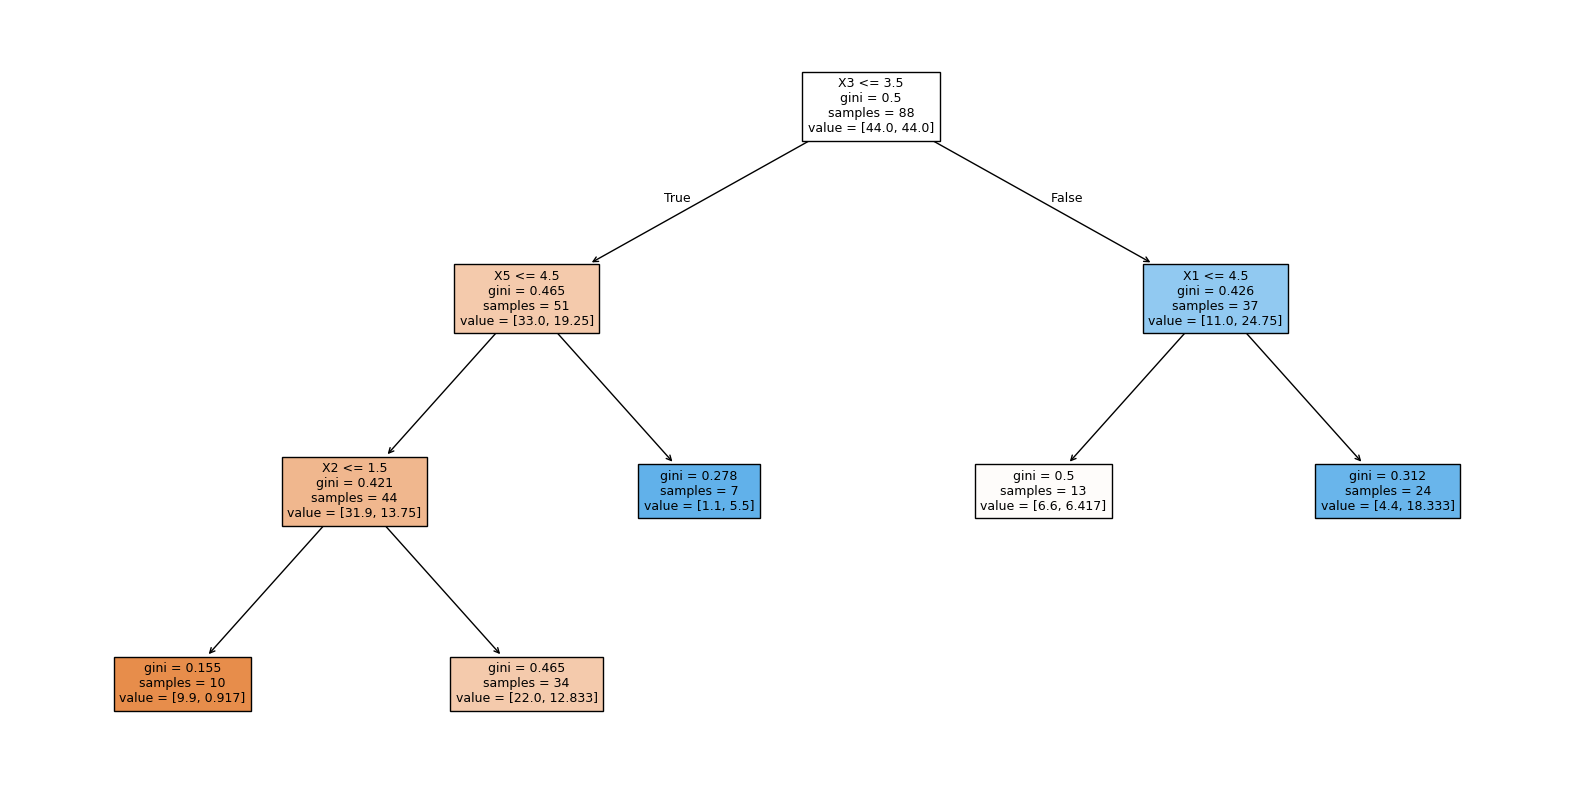

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()


* We can see gini impurity is high in two leaf nodes which is not good for our prediction.

### **Advanced Models**

>> We will try other robust models to see if data generalize well and we can get best accuracy.
Since we have 126 rows, we can't split data into training, validation and testing sets. We will do hyper parameter tuning on training set and then at the end we will apply best model to testing set.


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))




Training Performance:

Bagging: 0.9375
Random forest: 0.9375
GBM: 0.8958333333333334
Adaboost: 0.7291666666666666
dtree: 0.875
XGBoost: 0.9166666666666666


* We will hyper parameter tuning on Random forest and Bagging model to get the best and generalize accuracy.

> **Hyper Parameter Tuning on Random Forest**

Best hyper‑parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': np.int64(5)}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.852   0.875      0.857 0.866

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.579   0.429      0.692 0.529

Confusion matrix – training set

Confusion matrix – test set


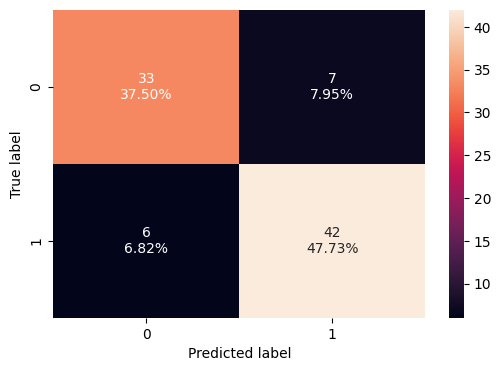

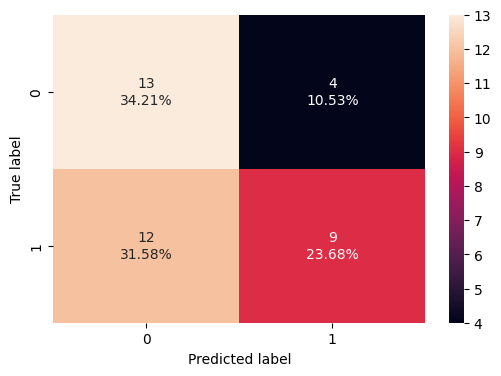

In [ ]:
# hyper–parameter tuning for a random‑forest classifier and evaluation on
# both the training and the hold‑out test set

# base estimator
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# parameter grid / distribution (re‑use the one defined earlier if already present)
param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": np.arange(1, 7, 1),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
rf_train_perf = model_performance_classification_statsmodels(best_rf, X_train, y_train)
rf_test_perf = model_performance_classification_statsmodels(best_rf, X_test, y_test)

print("\nRandom‑forest performance on training set:")
print(rf_train_perf)

print("\nRandom‑forest performance on test set:")
print(rf_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_statsmodels(best_rf, X_train, y_train)
print("\nConfusion matrix – test set")
confusion_matrix_statsmodels(best_rf, X_test, y_test)

* Hyper tuned Random forest didn’t generalize well on testing data

> **Hyper parameter tuning on Bagging**




Best hyper‑parameters: {'n_estimators': 70, 'max_samples': 1, 'max_features': 0.8}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.545   1.000      0.545 0.706

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.553   1.000      0.553 0.712

Confusion matrix – training set

Confusion matrix – test set


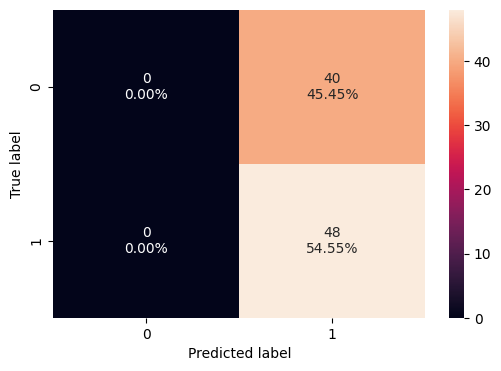

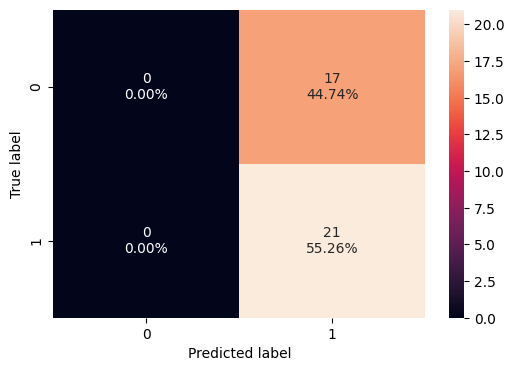

In [ ]:
# hyper–parameter tuning for a Bagging classifier and evaluation on
# both the training and the hold‑out test set

# base estimator
Bagging_tuned = BaggingClassifier(random_state=1)

# parameter grid / distribution (re‑use the one defined earlier if already present)
param_dist = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(precision_score)

search = RandomizedSearchCV(Bagging_tuned, param_dist, cv=5, scoring=acc_scorer)
search.fit(X_train, y_train)

best_bagging_tuned = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
Bagging_train_perf = model_performance_classification_statsmodels(best_bagging_tuned, X_train, y_train)
Bagging_test_perf = model_performance_classification_statsmodels(best_bagging_tuned, X_test, y_test)

print("\nRandom‑forest performance on training set:")
print(Bagging_train_perf)

print("\nRandom‑forest performance on test set:")
print(Bagging_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_statsmodels(best_bagging_tuned, X_train, y_train)
print("\nConfusion matrix – test set")
confusion_matrix_statsmodels(best_bagging_tuned, X_test, y_test)

* Random forest and Bagging couldn't give best performance on training and testing sets.
* Company should collect more data to use this robust model to generalize well on data.


### **Approach 4**
* Now let's look at the Data Description:

Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers
X1 = my order was delivered on time<br>
X2 = contents of my order was as I expected<br>
X3 = I ordered everything I wanted to order<br>
X4 = I paid a good price for my order<br>
X5 = I am satisfied with my courier<br>
X6 = the app makes ordering easy for me

Attributes X1 to X6 indicate the responses for each question and have values from 1 to 5 where the smaller number indicates less and the higher number indicates more towards the answer.
* If I would a be happy customer, I would give my rating average 3 for above survey. So we can use feature engineering to add column at the end, called avg_X. We can use this approach to predict y variable using effective threshold. Sometimes it can get biased if I am a happy customer and I am giving 1 rating to one category and 3 rating to remaining category.


In [ ]:

# Calculate the mean of X1 to X6 for each row
df['X_mean'] = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6']].mean(axis=1)


# Display the first few rows to verify
print(df.head())

   Y  X1  X2  X3  X4  X5  X6  X_mean
0  0   3   3   3   4   2   4   3.167
1  0   3   2   3   5   4   3   3.333
2  1   5   3   3   3   3   5   3.667
3  0   5   4   3   3   3   5   3.833
4  0   5   4   3   3   3   5   3.833


In [ ]:
# Features and target
X = df.drop(['Y', 'X1','X2', 'X3', 'X4', 'X5','X6'], axis=1)
y = df['Y']

# adding a constant to the independent variables
X = sm.add_constant(X)

# Train-test split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
logit2 = sm.Logit(y_train, X_train.astype(float))
lg2 = logit2.fit(disp=False)
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       86
Method:                           MLE   Df Model:                            1
Date:                Wed, 25 Feb 2026   Pseudo R-squ.:                 0.01142
Time:                        21:19:19   Log-Likelihood:                -59.940
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.2393
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5256      1.486     -1.027      0.305      -4.438       1.387
X_mean         0.4731      0.408      1.160      0.246      -0.326       1.272


In [ ]:
print("Training performance:")
model_performance_classification_statsmodels(lg2, X_train, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.568,0.854,0.569,0.683


In [ ]:
log_reg_model_test_perf = model_performance_classification_statsmodels(
    lg2, X_test, y_test
)

print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.658,0.905,0.633,0.745


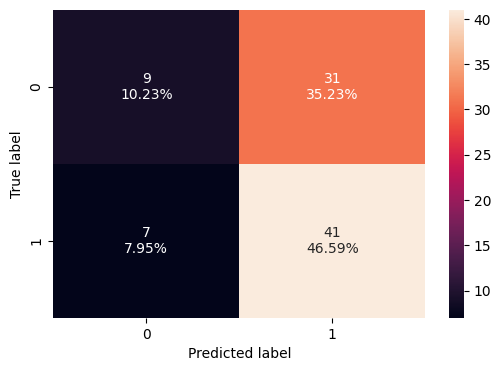

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg2, X_train, y_train)

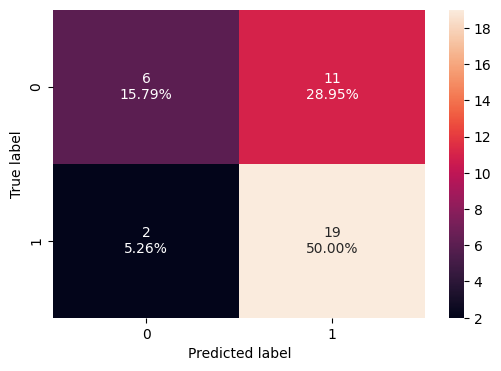

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg2, X_test, y_test)

* This model using avg_X as a independent variable to predict y variable did generalize well on training and testing set with 905 recall and 63% precision in testing set without overfitting.
* If company needs a simple model with less resources (time and CPU or GPU usage), they can use this model.


>> **Final Approach**<br>
* We can see the robust models like decision tree, Random forest , Bagging and Xgboost classifiers couldn’t generalize accuracy on both training and testing sets. The company will need to provide more data to analyze the results again.
* We can choose to go with logistic regression model. Furthermore we can use precision-recall curve to choose best recall and precision for our model


### Precision-Recall Curve

In [ ]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train)
lg = logit.fit(disp=False)
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       82
Method:                           MLE   Df Model:                            5
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                 0.04446
Time:                        18:42:01   Log-Likelihood:                -57.937
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.3700
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
X1             0.0347      0.324      0.107      0.915      -0.599       0.669
X2            -0.1673      0.212     -0.789      0.430      -0.583       0.248
X3             0.2009      0.238      0.843      0.3

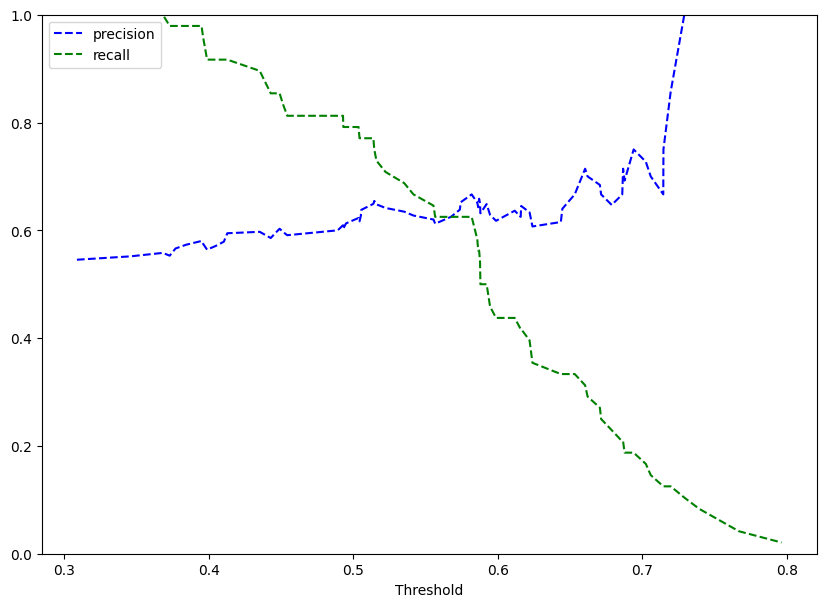

In [ ]:
y_scores = lg.predict(X_train)
prec, rec, tre = precision_recall_curve(y_train, y_scores)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

In [ ]:
# setting the threshold
optimal_threshold_curve = 0.48

> We will choose our optimal thresold 0.38 and use cross validation to optimize the model.



In [ ]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train)
logit_final = logit.fit(threshold=optimal_threshold_curve, cv=5)
print(lg.summary())

Optimization terminated successfully.
         Current function value: 0.658375
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       82
Method:                           MLE   Df Model:                            5
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                 0.04446
Time:                        19:05:41   Log-Likelihood:                -57.937
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.3700
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
X1             0.0347      0.324      0.107      0.915      -0.599       0.669
X2            -0.1673      0.

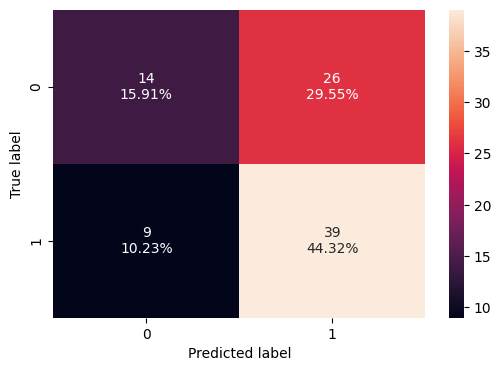

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(logit_final, X_train, y_train, threshold=optimal_threshold_curve)

In [ ]:
log_reg_model_train_perf_threshold_curve = model_performance_classification_statsmodels(
    logit_final, X_train, y_train, threshold=optimal_threshold_curve
)
print("Training performance:")
log_reg_model_train_perf_threshold_curve

Training performance:


,Accuracy,Recall,Precision,F1
0,0.602,0.812,0.600,0.690


In [ ]:
log_reg_model_test_perf_threshold_curve = model_performance_classification_statsmodels(
    logit_final, X_test, y_test, threshold=optimal_threshold_curve
)
print("Test performance:")
log_reg_model_test_perf_threshold_curve

Test performance:


,Accuracy,Recall,Precision,F1
0,0.526,0.810,0.548,0.654


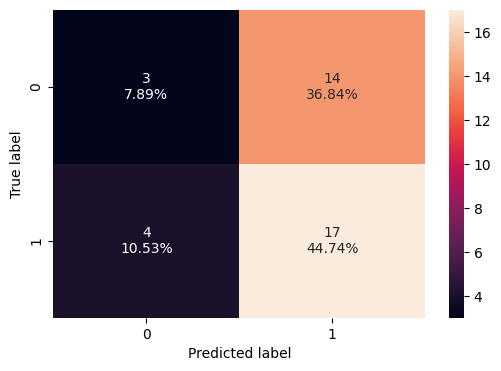

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(logit_final, X_test, y_test, threshold=optimal_threshold_curve)

* Logistic model with 0.48 threshold gave a best performance with 81% Recall and 55% precision. And both generalized well on training and testing data sets well.

>> **Feature Elimination**
* The company is very interested in finding which questions/features are more important when predicting a customer’s happiness. Using a feature selection approach show them understand what is the minimal set of attributes/features that would preserve the most information about the problem while increasing predictability of the data they have. Is there any question that they can remove in our next survey?
* We can run feature importance on our logistic regression model and decide which features are less important

In [ ]:
# converting coefficients to odds
odds = np.exp(logit_final.params)

# finding the percentage change
perc_change_odds = (np.exp(logit_final.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train.columns).T

,X1,X2,X3,X4,X5,X6
Odds,1.035,0.846,1.223,0.929,1.384,0.783
Change_odd%,3.528,-15.408,22.255,-7.147,38.366,-21.666


* Holding all other features constant a 1 unit change in X5 will increase the odds of getting happy customer by ~1.38 times or a ~38% increase in odds of booking getting canceled.
* Holding all other features constant a 1 unit change in X1 will increase the odds of a booking getting canceled by ~1.03 times or a increase of ~3.5% decrease in odds of booking getting canceled.
* Holding all other features constant a 1 unit change in X4 will decrease the odds of getting happy customer by ~0.92 times or a ~7% decrease in odds of booking getting canceled.
* According to the model X5 and X3 are most important features while X1 and X4 are least important features
